In [1]:
# ============================================
# Objective 3: Ratings → Sales Performance Model
# ============================================

import pandas as pd
import numpy as np
import re

import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import pearsonr

# -----------------------------
# 0) LOAD & PREP DATA
# -----------------------------
file_path = "TOP 2500 final.xlsx"   # change path if needed

# Read both sheets
top = pd.read_excel(file_path, sheet_name="TOP 2500")
bottom = pd.read_excel(file_path, sheet_name="BOTTOM 2500")

# Standardize column names
rename_map = {
    "TOTAL QUANTITY": "sales",
    "QUANTITY": "sales",
    "Total Images": "images",
    "Total Videos": "videos",
    "Rating": "rating",
    "A & A+ Content": "a_plus",
    "A & A+": "a_plus",
    "Classification": "category",
    "Review Count": "review_count"
}

top = top.rename(columns=rename_map)
bottom = bottom.rename(columns=rename_map)

# Combine into single dataframe
df = pd.concat([top, bottom], ignore_index=True)

# -----------------------------
# 1) CLEAN RATING & SALES
# -----------------------------

# Clean rating strings like "4.5 out of 5 stars" → 4.5
def clean_rating(x):
    if pd.isna(x):
        return np.nan
    m = re.search(r'([0-5](?:\.\d)?)', str(x))
    return float(m.group(1)) if m else np.nan

df["rating_num"] = df["rating"].apply(clean_rating)

# Ensure sales numeric
df["sales"] = pd.to_numeric(df["sales"], errors="coerce")

# If review_count column is missing, create it as 0
if "total_reviews" not in df.columns:
    df["total_reviews"] = 0
else:
    df["total_reviews"] = pd.to_numeric(df["total_reviews"], errors="coerce").fillna(0)

# Drop rows without rating or sales
data = df.dropna(subset=["rating_num", "sales"]).copy()

print("Data used for Objective 3 modelling:")
print(data[["rating_num", "sales", "review_count"]].head())

# -----------------------------
# 2) PEARSON CORRELATION: Rating ↔ Sales
# -----------------------------
corr, pval = pearsonr(data["rating_num"], data["sales"])

print("\n=== PEARSON CORRELATION: Rating vs Sales ===")
print(f"Correlation coefficient = {corr:.4f}")
print(f"P-value                 = {pval:.5f}")

# -----------------------------
# 3) SIMPLE LINEAR REGRESSION: sales ~ rating_num
# -----------------------------
model_simple = smf.ols("sales ~ rating_num", data=data).fit()

print("\n=== SIMPLE LINEAR REGRESSION: sales ~ rating_num ===")
print(model_simple.summary())

# Interpretation help:
# - The coefficient for rating_num tells you how many units of sales
#   change for a 1-star increase in rating, on average.

# -----------------------------
# 4) MULTIPLE REGRESSION: sales ~ rating_num + review_count + category
# -----------------------------
# If category column is missing, create a dummy to avoid error
if "category" not in data.columns:
    data["category"] = "Unknown"

model_multi = smf.ols(
    "sales ~ rating_num + review_count + C(category)",
    data=data
).fit()

print("\n=== MULTIPLE REGRESSION: "
      "sales ~ rating_num + review_count + category ===")
print(model_multi.summary())

# Interpretation help:
# - rating_num coefficient = effect of rating controlling for review_count & category
# - review_count coefficient = additional impact of more reviews
# - C(category) terms = category-level differences in baseline sales



Data used for Objective 3 modelling:
   rating_num  sales  review_count
0         4.8   1983           958
1         4.7   1331          1090
2         4.6    810           640
3         4.4    508            34
4         4.6    415           667

=== PEARSON CORRELATION: Rating vs Sales ===
Correlation coefficient = -0.0068
P-value                 = 0.68787

=== SIMPLE LINEAR REGRESSION: sales ~ rating_num ===
                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.1614
Date:                Wed, 03 Dec 2025   Prob (F-statistic):              0.688
Time:                        00:52:53   Log-Likelihood:                -18581.
No. Observations:                3454   AIC:                         3.717e+04
Df Residuals:                   

In [9]:
# =======================================================
# Objective 3 (Total Reviews Only):
# Measure how total reviews influence sales performance
# =======================================================

import pandas as pd
import numpy as np
import re
import statsmodels.formula.api as smf
from scipy.stats import pearsonr

# -----------------------------
# 0) LOAD & PREP DATA
# -----------------------------
file_path = "TOP 2500 final.xlsx"   # update path if needed

# Load both sheets
top = pd.read_excel(file_path, sheet_name="TOP 2500")
bottom = pd.read_excel(file_path, sheet_name="BOTTOM 2500")

# Standardize column names
rename_map = {
    "TOTAL QUANTITY": "sales",
    "QUANTITY": "sales",
    "Review Count": "total_reviews",
    "Classification": "category"
}

top = top.rename(columns=rename_map)
bottom = bottom.rename(columns=rename_map)

# Combine
df = pd.concat([top, bottom], ignore_index=True)

# -----------------------------
# 1) Ensure numeric columns
# -----------------------------
df["sales"] = pd.to_numeric(df["sales"], errors="coerce")
df["total_reviews"] = pd.to_numeric(df["total_reviews"], errors="coerce")

# Clean dataset
data = df.dropna(subset=["sales", "total_reviews"]).copy()

print("Data sample:")
print(data[["sales", "total_reviews"]].head())

# =======================================================
# 2) PEARSON CORRELATION: Total Reviews vs Sales
# =======================================================

corr, pval = pearsonr(data["total_reviews"], data["sales"])

print("\n=== PEARSON CORRELATION: Total Reviews vs Sales ===")
print(f"Correlation coefficient = {corr:.4f}")
print(f"P-value                 = {pval:.5f}")

# =======================================================
# 3) SIMPLE REGRESSION: sales ~ total_reviews
# =======================================================

model_simple = smf.ols("sales ~ total_reviews", data=data).fit()

print("\n=== SIMPLE REGRESSION: sales ~ total_reviews ===")
print(model_simple.summary())

# =======================================================
# 4) MULTIPLE REGRESSION:
#    sales ~ total_reviews + category
# =======================================================

if "category" not in data.columns:
    data["category"] = "Unknown"

model_multi = smf.ols(
    "sales ~ total_reviews + C(category)",
    data=data
).fit()

print("\n=== MULTIPLE REGRESSION: sales ~ total_reviews + category ===")
print(model_multi.summary())

Data sample:
   sales  total_reviews
0   1983            958
1   1331           1090
2    810            640
3    508             34
4    415            667

=== PEARSON CORRELATION: Total Reviews vs Sales ===
Correlation coefficient = 0.4640
P-value                 = 0.00000

=== SIMPLE REGRESSION: sales ~ total_reviews ===
                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.215
Model:                            OLS   Adj. R-squared:                  0.215
Method:                 Least Squares   F-statistic:                     1371.
Date:                Wed, 03 Dec 2025   Prob (F-statistic):          1.84e-265
Time:                        00:55:40   Log-Likelihood:                -25416.
No. Observations:                5001   AIC:                         5.084e+04
Df Residuals:                    4999   BIC:                         5.085e+04
Df Model:                           1    

In [13]:
# === 1. Recreate df_hg (same cleaning steps you used before) ===

# Load your file
file_path = "TOP 2500 final.xlsx"

top = pd.read_excel(file_path, sheet_name="TOP 2500")
bottom = pd.read_excel(file_path, sheet_name="BOTTOM 2500")

# Standard rename map
rename_map = {
    "TOTAL QUANTITY": "sales",
    "QUANTITY": "sales",
    "Total Images": "images",
    "Total Videos": "videos",
    "Rating": "rating",
    "A & A+ Content": "a_plus",
    "A & A+": "a_plus",
    "Classification": "category",
    "Review Count": "total_reviews"
}

top = top.rename(columns=rename_map)
bottom = bottom.rename(columns=rename_map)

# Combine into df
df = pd.concat([top, bottom], ignore_index=True)

# Clean sales
df["sales"] = pd.to_numeric(df["sales"], errors="coerce")

# Create df_hg
df_hg = df.dropna(subset=["sales"]).copy()

# Clean review_count
df_hg["total_reviews"] = pd.to_numeric(df_hg["total_reviews"], errors="coerce").fillna(0)

# === 2. Count review counts ===

zero_reviews = (df_hg["total_reviews"] == 0).sum()
non_zero_reviews = (df_hg["total_reviews"] > 0).sum()
total_rows = len(df_hg)

print("=== REVIEW COUNT SUMMARY ===")
print(f"Total products:            {total_rows}")
print(f"Products with 0 reviews:   {zero_reviews}")
print(f"Products with >0 reviews:  {non_zero_reviews}")
print(f"Percent with 0 reviews:    {zero_reviews/total_rows*100:.2f}%")


=== REVIEW COUNT SUMMARY ===
Total products:            5001
Products with 0 reviews:   1709
Products with >0 reviews:  3292
Percent with 0 reviews:    34.17%


In [15]:
#Importing the relevant libraries
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np 

from scipy.stats import pearsonr

In [17]:
df_top = pd.read_excel("TOP 2500 final.xlsx", sheet_name="TOP 2500")
df_bottom = pd.read_excel("TOP 2500 final.xlsx", sheet_name="BOTTOM 2500")

# Add seller group labels
df_top["seller_group"] = "Top Sellers"
df_bottom["seller_group"] = "Bottom Sellers"

# Combine them back
df = pd.concat([df_top, df_bottom], ignore_index=True)

print(df["seller_group"].value_counts())

#Standardize the columns 
def snake(s):
    return (str(s)
            .strip()
            .lower()
            .replace(" ", "_")
            .replace("&", "and")
            .replace("+", "plus")
            .replace("%", "pct"))

df.columns = [snake(c) for c in df.columns]

print(df.columns)

qty_col = "total_quantity"
rating_col = "rating"

# Convert both to numeric safely
df["qty"] = pd.to_numeric(df[qty_col], errors="coerce")
df["rating_clean"] = pd.to_numeric(df[rating_col], errors="coerce")
len(df["sku"])

#Drop missing rows 
corr_data = df.dropna(subset=["qty", "rating_clean"]).copy()
corr_data.size

print("Rows used for correlation:", len(corr_data))

seller_group
Bottom Sellers    2501
Top Sellers       2500
Name: count, dtype: int64
Index(['sku', 'asin', 'total_quantity', 'descrption', 'auction_title',
       'a_and_aplus_content', 'classification', 'rating', 'review_count',
       'total_images', 'total_videos', 'brand_text_length', 'brand_keywords',
       'brand_sentiment_words', 'description_length', 'top_keywords',
       'unique_keyword_count', 'sentiment_keywords', 'seller_group',
       'quantity', 'description', 'auction_title', 'a_and_aplus'],
      dtype='object')
Rows used for correlation: 2251


In [19]:
# 1) Compute Pearson correlation (linear relationship)
corr_value, p_value = pearsonr(
    corr_data["rating_clean"],
    corr_data["qty"]
)

print("Pearson correlation coefficient:", corr_value) ##0.01
print("P-value:", p_value) ##0.59

##Interpretation of the Correlation test 
'''no meaningful linear relationship between customer ratings and total quantity sold (r = 0.011, p = 0.598).'''
''' Ratings do not significantly influence sales performance across Novica’s SKUs.”'''

Pearson correlation coefficient: 0.011130534312209766
P-value: 0.5976326480490953


' Ratings do not significantly influence sales performance across Novica’s SKUs.”'

C:\Users\32lio\AppData\Local\Temp\ipykernel_42960\2057189582.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


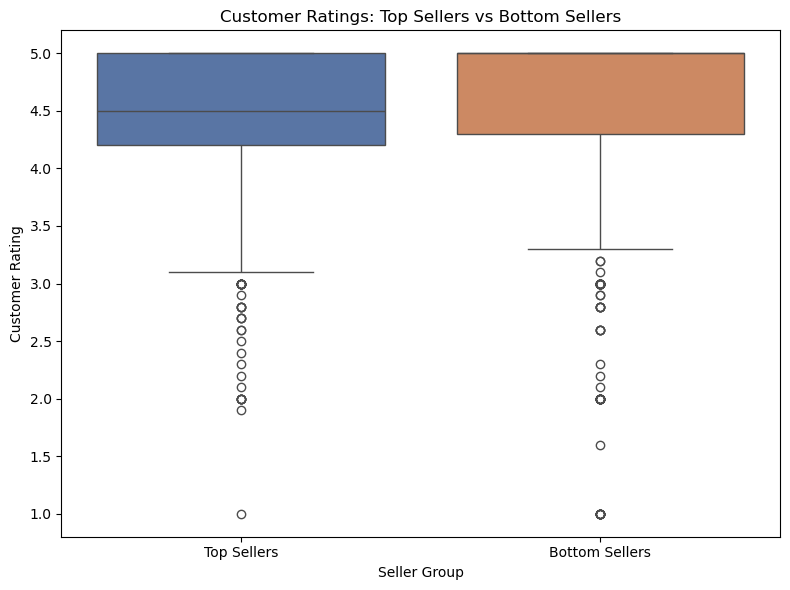

In [21]:
#Visualization to showcase the interpretation 

df["rating_bucket"] = pd.cut(
    df["rating_clean"],
    bins=[0, 3.5, 4.0, 4.5, 5.0],
    labels=["Low", "Average", "Good", "Excellent"],
    include_lowest=True
)

plt.figure(figsize=(8,6))

sns.boxplot(
    data=df[df["seller_group"].isin(["Top Sellers", "Bottom Sellers"])],
    x="seller_group",
    y="rating_clean",
    palette="deep"
)

plt.title("Customer Ratings: Top Sellers vs Bottom Sellers")
plt.xlabel("Seller Group")
plt.ylabel("Customer Rating")

plt.tight_layout()
plt.show()

#A higher customer rating does not lead to higher sales.